In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df=pd.read_csv('testset.csv')
df


,datetime_utc,_conds,_dewptm,_fog,_hail,_heatindexm,_hum,_precipm,_pressurem,_rain,_snow,_tempm,_thunder,_tornado,_vism,_wdird,_wdire,_wgustm,_windchillm,_wspdm
0,19961101-11:00,Smoke,9.0,0,0,NaN,27.0,NaN,1010.0,0,0,30.0,0,0,5.0,280.0,West,NaN,NaN,7.4
1,19961101-12:00,Smoke,10.0,0,0,NaN,32.0,NaN,-9999.0,0,0,28.0,0,0,NaN,0.0,North,NaN,NaN,NaN
2,19961101-13:00,Smoke,11.0,0,0,NaN,44.0,NaN,-9999.0,0,0,24.0,0,0,NaN,0.0,North,NaN,NaN,NaN
3,19961101-14:00,Smoke,10.0,0,0,NaN,41.0,NaN,1010.0,0,0,24.0,0,0,2.0,0.0,North,NaN,NaN,NaN
4,19961101-16:00,Smoke,11.0,0,0,NaN,47.0,NaN,1011.0,0,0,23.0,0,0,1.2,0.0,North,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100985,20170424-06:00,Haze,17.0,0,0,NaN,25.0,NaN,1005.0,0,0,34.0,0,0,4.0,320.0,NW,NaN,NaN,11.1
100986,20170424-09:00,Haze,14.0,0,0,NaN,16.0,NaN,1003.0,0,0,38.0,0,0,4.0,320.0,NW,NaN,NaN,22.2
100987,20170424-12:00,Haze,12.0,0,0,NaN,14.0,NaN,1002.0,0,0,36.0,0,0,4.0,270.0,West,NaN,NaN,18.5
100988,20170424-15:00,Haze,15.0,0,0,NaN,27.0,NaN,1004.0,0,0,32.0,0,0,2.0,320.0,NW,NaN,NaN,3.7


In [20]:
df.columns = df.columns.str.strip()


In [21]:
 if '_tempm' not in df.columns:
    print("Error: '_tempm' column not found in dataset.")
else:
    # Replace invalid values and drop NaNs only if column exists
    df.replace(-9999.0, np.nan, inplace=True)
    df.dropna(subset=['_tempm'], inplace=True)
    
    print("Dataset cleaned successfully!")


Dataset cleaned successfully!


In [22]:
print(df.columns)  # Verify column names
print(df.head())  

Index(['datetime_utc', '_conds', '_dewptm', '_fog', '_hail', '_heatindexm',
       '_hum', '_precipm', '_pressurem', '_rain', '_snow', '_tempm',
       '_thunder', '_tornado', '_vism', '_wdird', '_wdire', '_wgustm',
       '_windchillm', '_wspdm'],
      dtype='object')
     datetime_utc _conds  _dewptm  _fog  _hail  _heatindexm  _hum  _precipm  \
0  19961101-11:00  Smoke      9.0     0      0          NaN  27.0       NaN   
1  19961101-12:00  Smoke     10.0     0      0          NaN  32.0       NaN   
2  19961101-13:00  Smoke     11.0     0      0          NaN  44.0       NaN   
3  19961101-14:00  Smoke     10.0     0      0          NaN  41.0       NaN   
4  19961101-16:00  Smoke     11.0     0      0          NaN  47.0       NaN   

   _pressurem  _rain  _snow  _tempm  _thunder  _tornado  _vism  _wdird _wdire  \
0      1010.0      0      0    30.0         0         0    5.0   280.0   West   
1         NaN      0      0    28.0         0         0    NaN     0.0  North   
2         N

In [23]:
features = ['_dewptm', '_hum', '_pressurem', '_wspdm']  # Choose related features
X = df[features].dropna()  # Drop NaN values in features
Y = df.loc[X.index, '_tempm']

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [25]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [26]:
Y_pred = model.predict(X_test)


In [27]:
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

In [28]:
print("Mean Squared Error:", mse)
print("R-squared Score:", r2)
print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Mean Squared Error: 6.312331419046988
R-squared Score: 0.912604467590358
Model Coefficients: [ 9.46615123e-01 -2.93807145e-01  8.14551907e-08  4.51730086e-02]
Intercept: 27.214351708706324


In [29]:
import matplotlib.pyplot as plt


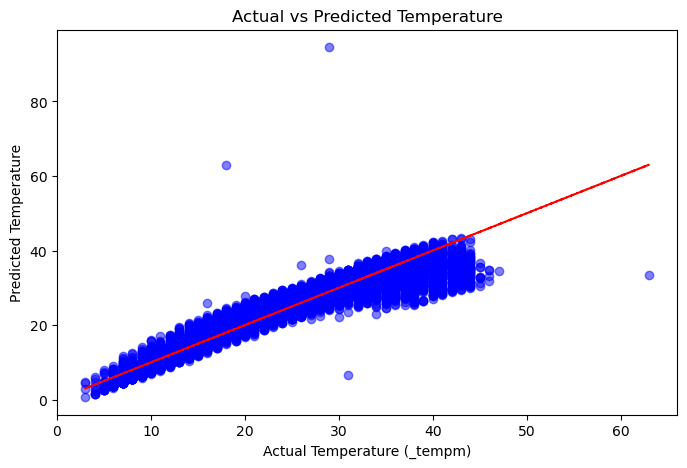

In [31]:
plt.figure(figsize=(8, 5))
plt.scatter(Y_test, Y_pred, color='blue', alpha=0.5)
plt.plot(Y_test, Y_test, color='red', linestyle='dashed')  # Ideal line
plt.xlabel("Actual Temperature (_tempm)")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()


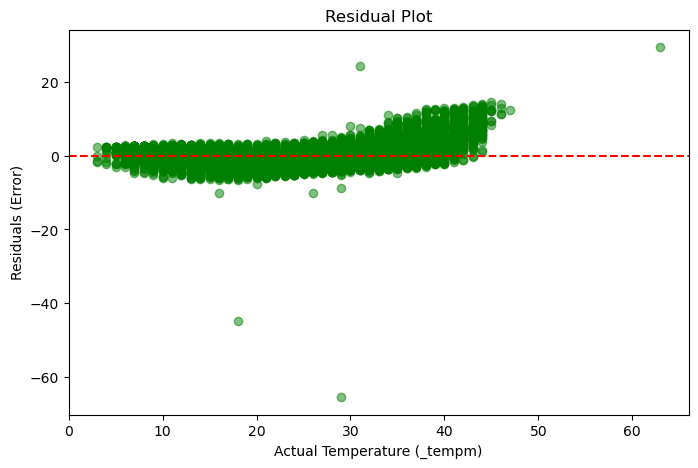

In [34]:
 # Residual Plot
residuals = Y_test - Y_pred
plt.figure(figsize=(8, 5))
plt.scatter(Y_test, residuals, color='green', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='dashed')
plt.xlabel("Actual Temperature (_tempm)")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")
plt.show()

In [35]:
train_accuracy = model.score(X_train, Y_train)
print("Training Accuracy (R² Score):", train_accuracy)

# Test Accuracy
test_accuracy = model.score(X_test, Y_test)
print("Test Accuracy (R² Score):", test_accuracy)

Training Accuracy (R² Score): 0.9142503976671594
Test Accuracy (R² Score): 0.912604467590358


In [38]:

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [39]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()
# Train Decision Tree Classifer
clf = clf.fit(X_train,Y_train)
#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [40]:
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[ 1,  2,  0, ...,  0,  0,  0],
       [ 3,  7,  0, ...,  0,  0,  0],
       [ 0,  0, 31, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=int64)

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 427.9555555555555, 'Predicted label')

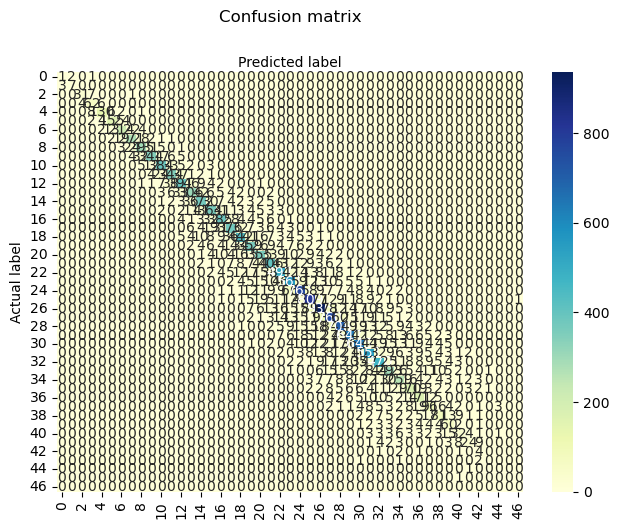

In [42]:
class_names=[0,1] # name of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(clf, filled=True)
plt.show()